In [7]:
import pickle
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open("./WS_Preprocessed/data/dataset_preprocessed_run_0.pkl", "rb") as f:
    data_dict = pickle.load(f)

In [3]:
# jet_tensor is a nested tensor of shape [num_events][num_jets (VARIABLE)][feats]
jet_tensor = data_dict["jets"]

# jet_trk_tensor is a awkward array of shape [num_events][num_jets (VARIABLE)][num_trks (VARIABLE)][feats]
jet_trk_tensor = data_dict["jet_trks"]

# all_trk_tensor is a nested tensor of shape [num_events][num_trks (VARIABLE)][feats]
all_trk_tensor = data_dict["all_trks"]

In [4]:
### NOTE: Torch nested tensors only support one variable dimension! Awkward arrays support more than one variable dimension!
print(jet_tensor.type)
print(jet_trk_tensor.type)
print(all_trk_tensor.type)

1000 * var * 6 * float32
1000 * var * var * 7 * float64
1000 * var * 7 * float64


In [5]:
print("Num Total Events: ", len(jet_tensor))

Num Total Events:  1000


In [32]:
high_Efrac=jet_tensor[:,:,-2]>0.3
low_Efrac=~high_Efrac

[59, 62, 43, 30, 43, 56, 36, 17, 55, ..., 54, 61, 54, 50, 13, 76, 28, 84, 59]


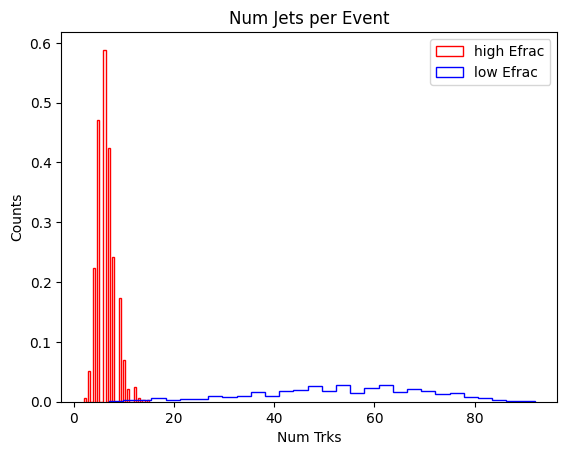

In [53]:
num_high_Efrac = ak.num(high_Efrac[high_Efrac==True], axis=1)
num_low_Efrac = ak.num(low_Efrac[low_Efrac==True], axis=1)
plt.title("Num Jets per Event")
plt.hist(ak.ravel(num_high_Efrac),bins=30,histtype='step',color='r', label='high Efrac', density=True)
plt.hist(ak.ravel(num_low_Efrac),bins=30,histtype='step',color='b', label='low Efrac', density=True)
plt.xlabel('Num Jets')
plt.ylabel('Counts')
plt.legend()
plt.show()

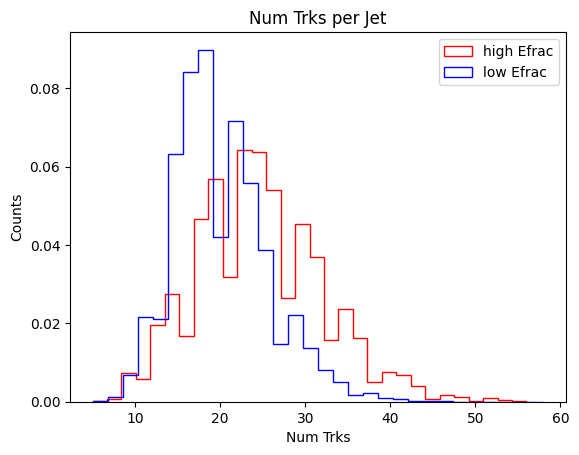

In [36]:
num_trks_jet = ak.num(jet_trk_tensor, axis=2)
plt.title("Num Trks per Jet")
plt.hist(ak.ravel(num_trks_jet[high_Efrac]),bins=30,histtype='step',color='r', label='high Efrac', density=True)
plt.hist(ak.ravel(num_trks_jet[low_Efrac]),bins=30,histtype='step',color='b', label='low Efrac', density=True)
plt.xlabel('Num Trks')
plt.ylabel('Counts')
plt.legend()
plt.show()

In [62]:
isHS=all_trk_tensor[:,:,-1]==-1
isPU=~isHS

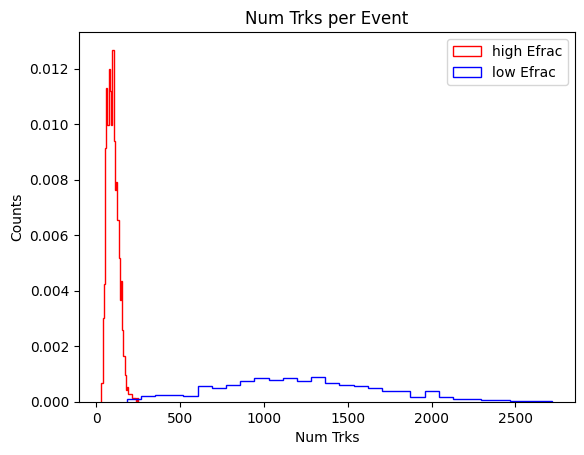

In [68]:
num_trks_HS_event = ak.num(isHS[isHS==True], axis=1)
num_trks_PU_event = ak.num(isPU[isPU==True], axis=1)
plt.title("Num Trks per Event")
plt.hist(ak.ravel(num_trks_HS_event),bins=30,histtype='step',color='r', label='high Efrac', density=True)
plt.hist(ak.ravel(num_trks_PU_event),bins=30,histtype='step',color='b', label='low Efrac', density=True)
plt.xlabel('Num Trks')
plt.ylabel('Counts')
plt.legend()
plt.show()

In [ ]:
plt.title("Jet Labels")
plt.hist(np.ravel(jet_Efrac),bins=50,range=(0,1),histtype='step',color='r',label="Efrac")
plt.hist(np.ravel(jet_Mfrac),bins=50,range=(0,1),histtype='step',color='b',label="Mfrac")
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
plt.title("jet_pT")
jet_pT=np.array(jet_pT)
jet_Efrac=np.array(jet_Efrac)
plt.hist(jet_pT[jet_Efrac>0.2],bins=50,range=(0,10),histtype='step',color='r',label="High Efrac Jets")
plt.hist(jet_pT[jet_Efrac<=0.2],bins=50,range=(0,10),histtype='step',color='b',label="Low Efrac Jets")
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
plt.title("jet_eta")
jet_eta=np.array(jet_eta)
jet_Efrac=np.array(jet_Efrac)
plt.hist(jet_eta[jet_Efrac>0.2],bins=50,range=(-3,3),histtype='step',color='r',label="High Efrac Jets",density=True)
plt.hist(jet_eta[jet_Efrac<=0.2],bins=50,range=(-3,3),histtype='step',color='b',label="Low Efrac Jets",density=True)
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
plt.title("jet_phi")
jet_phi=np.array(jet_phi)
jet_Efrac=np.array(jet_Efrac)
plt.hist(jet_phi[jet_Efrac>0.2],bins=50,range=(-3,3),histtype='step',color='r',label="High Efrac Jets",density=True)
plt.hist(jet_phi[jet_Efrac<=0.2],bins=50,range=(-3,3),histtype='step',color='b',label="Low Efrac Jets",density=True)
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
plt.title("jet_m")
jet_m=np.array(jet_m)
jet_Efrac=np.array(jet_Efrac)
plt.hist(jet_m[jet_Efrac>0.2],bins=50,range=(-3,20),histtype='step',color='r',label="High Efrac Jets",density=True)
plt.hist(jet_m[jet_Efrac<=0.2],bins=50,range=(-3,20),histtype='step',color='b',label="Low Efrac Jets",density=True)
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
plt.title("trk_pT")
trk_pT=np.array(trk_pT)
trk_isPU=np.array(trk_isPU)
plt.hist(trk_pT[trk_isPU==0],bins=50,range=(0,50),histtype='step',color='r',label="HS")
plt.hist(trk_pT[trk_isPU==1],bins=50,range=(0,50),histtype='step',color='b',label="PU")
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
plt.title("trk_eta")
trk_eta=np.array(trk_eta)
trk_isPU=np.array(trk_isPU)
plt.hist(trk_eta[trk_isPU==0],bins=50,range=(-3,3),histtype='step',color='r',label="HS",density=True)
plt.hist(trk_eta[trk_isPU==1],bins=50,range=(-3,3),histtype='step',color='b',label="PU",density=True)
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
plt.title("trk_phi")
trk_phi=np.array(trk_phi)
trk_isPU=np.array(trk_isPU)
plt.hist(trk_phi[trk_isPU==0],bins=50,range=(-3,3),histtype='step',color='r',label="HS",density=True)
plt.hist(trk_phi[trk_isPU==1],bins=50,range=(-3,3),histtype='step',color='b',label="PU",density=True)
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
plt.title("trk_q")
trk_q=np.array(trk_q)
trk_isPU=np.array(trk_isPU)
plt.hist(trk_q[trk_isPU==0],bins=50,range=(-3,3),histtype='step',color='r',label="HS",density=True)
plt.hist(trk_q[trk_isPU==1],bins=50,range=(-3,3),histtype='step',color='b',label="PU",density=True)
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
plt.title("trk_d0")
trk_d0=np.array(trk_d0)
trk_isPU=np.array(trk_isPU)
plt.hist(trk_d0[trk_isPU==0],bins=50,range=(-5,5),histtype='step',color='r',label="HS",density=True)
plt.hist(trk_d0[trk_isPU==1],bins=50,range=(-5,5),histtype='step',color='b',label="PU",density=True)
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
plt.title("trk_z0")
trk_z0=np.array(trk_z0)
trk_isPU=np.array(trk_isPU)
plt.hist(trk_z0[trk_isPU==0],bins=50,range=(-5,5),histtype='step',color='r',label="HS",density=True)
plt.hist(trk_z0[trk_isPU==1],bins=50,range=(-5,5),histtype='step',color='b',label="PU",density=True)
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
plt.title("Num Jets per Event")
num_jets_per_event=np.array(num_jets_in_event)
plt.hist(num_jets_per_event,bins=30,range=(0,100),histtype='step',color='r')
#plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
plt.title("Num Trks per Jet")
num_trks_per_jet=np.array(num_trks_in_jet)
jet_Efrac=np.array(jet_Efrac)
plt.hist(num_trks_per_jet[jet_Efrac>0.2],bins=50,range=(0,100),histtype='step',color='r',label="High Efrac Jets")
plt.hist(num_trks_per_jet[jet_Efrac<=0.2],bins=50,range=(0,100),histtype='step',color='b',label="Low Efrac Jets")
plt.legend()
plt.yscale('log')
plt.show()